In [66]:
import numpy as np
import matplotlib.pyplot as plt

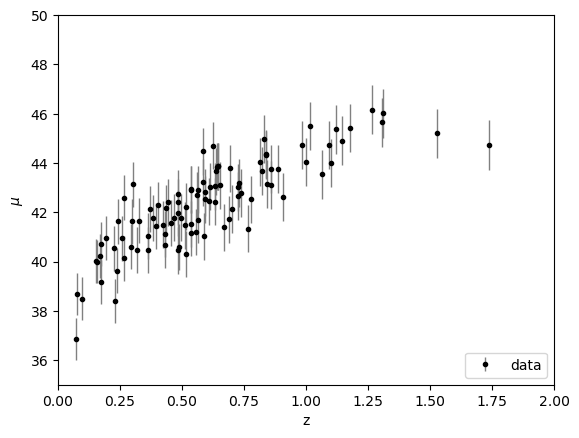

In [67]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

39.56505554722625 [4.64711848]
(2,)
(2, 1)


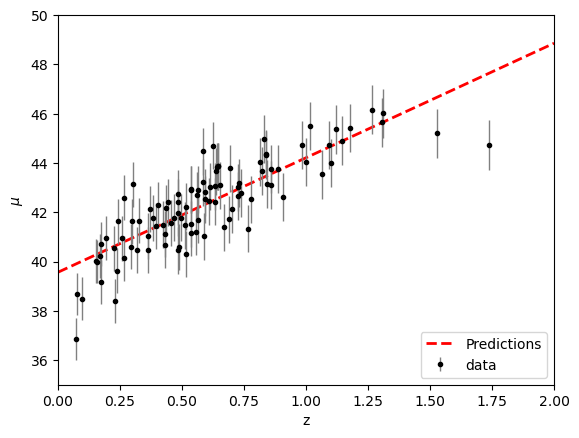

In [68]:
#LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

x = np.reshape(z_sample, [100, 1])
y = mu_sample
X_new = np.array([[0], [2]])

lin_reg = LinearRegression()
lin_reg.fit(x, y, sample_weight=1.0)

theta0 = lin_reg.intercept_
theta1 = lin_reg.coef_

print(theta0, theta1)
y_pred = lin_reg.predict(X_new)

print(np.shape(y_pred))
print(np.shape(X_new))

plt.plot(X_new, y_pred, "r--", linewidth=2, label="Predictions")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

(100,)
(100, 1)
[38.49130243  8.23905057 -2.20391808 -0.15168104]


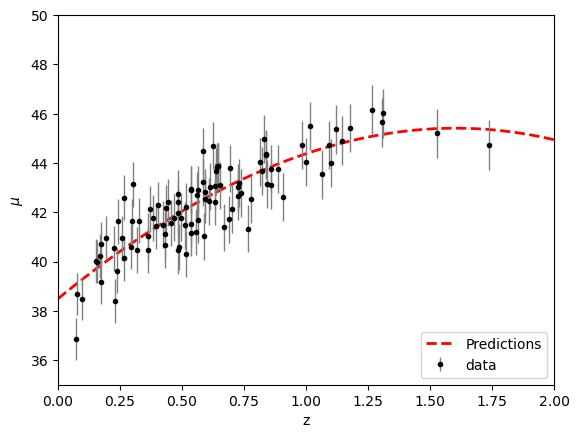

In [80]:
#POLINOMIAL REGRESSION

from astroML.linear_model import PolynomialRegression

x = np.reshape(z_sample, [100, 1])
y = mu_sample
X_new = np.reshape(np.linspace(0, 2, 100), [100, 1])

degree = 3
model = PolynomialRegression(degree) # fit 3rd degree polynomial
model.fit(x, y)
y_pred2 = model.predict(X_new)

print(np.shape(y_pred2))
print(np.shape(X_new))

n_constraints = degree + 1
print(model.coef_)

plt.plot(X_new, y_pred2, "r--", linewidth=2, label="Predictions")
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);